# Análisis de Similitud Curricular — Nivel 3: Vectores de Habilidades ESCO

**Proyecto:** TIC-D — Análisis de similitud curricular entre carreras de la EPN y universidades OCDE  
**Autor:** Glenn  
**Institución:** Escuela Politécnica Nacional (EPN)  

---

## ¿Qué problema resuelve este análisis?

El Nivel 1 (TF-IDF) compara carreras por **palabras exactas**. Si dos universidades describen la misma competencia con vocabulario distinto, TF-IDF las ve como diferentes. Por ejemplo:

- EPN dice: *"diseña e implementa sistemas de software"*
- ESPOL dice: *"desarrolla y construye soluciones informáticas"*

TF-IDF vería esto como muy diferente porque no comparte palabras. Semánticamente, son casi idénticas.

El Nivel 3 resuelve esto usando **ESCO** (European Skills, Competences, Qualifications and Occupations) como vocabulario común estandarizado. En lugar de comparar texto contra texto, proyectamos cada carrera al espacio de habilidades ESCO y comparamos esas proyecciones.

---

## El pipeline completo del Nivel 3

```
PASO 1: Texto de carrera
        perfil_egreso + perfil_profesional
        ↓
PASO 2: Embedding semántico (BGE-M3 o E5-Large)
        texto → vector denso de 1024 dimensiones
        ↓
PASO 3: Comparación contra 4241 habilidades ESCO
        similitud coseno: carrera vs cada habilidad
        → vector de 4241 scores por carrera
        ↓
PASO 4: Matriz de similitud carrera × carrera
        similitud coseno entre vectores ESCO de cada par de carreras
        → matriz 163 × 163
        ↓
PASO 5: Clustering jerárquico + visualizaciones
        dendrograma, heatmap, métricas
```

**Prerequisito:** Haber ejecutado `analysis/esco_mapping.py` previamente para generar los vectores.

---

## Cómo usar este notebook

Cada sección es **independiente** — puedes ejecutar solo la que necesitas.  
El único prerequisito es ejecutar siempre primero la **Sección 0** (configuración) y la **Sección 1** (carga de datos).

Para cambiar de modelo, ve a la Sección 1 y modifica la variable `MODELO`.

---
## Sección 0 — Configuración e Imports

**Qué hace esta celda:**  
Importa todas las librerías necesarias y define las rutas a los archivos del proyecto.

**Librerías y su función:**

| Librería | Para qué se usa |
|---|---|
| `pandas` | Cargar y manipular el CSV de carreras y habilidades |
| `numpy` | Operaciones sobre matrices numéricas (vectores, similitudes) |
| `matplotlib` | Generar todas las visualizaciones (heatmap, tabla, métricas) |
| `scipy.cluster.hierarchy` | Clustering jerárquico: `linkage` construye el árbol, `dendrogram` lo dibuja, `cophenet` calcula la métrica de calidad, `fcluster` corta el árbol en k grupos, `leaves_list` obtiene el orden de las hojas |
| `scipy.spatial.distance` | `squareform` convierte entre matriz cuadrada y forma condensada (la que necesita `linkage`) |
| `sklearn.metrics.pairwise` | `cosine_similarity` calcula similitud coseno entre vectores |
| `sklearn.metrics` | `silhouette_score` evalúa la calidad de los clusters |
| `matplotlib.colors.TwoSlopeNorm` | Normalización de color con rango dinámico para el heatmap |

**Cuándo ejecutar:** Siempre primero. Si reinicias el kernel de Jupyter, vuelve a ejecutar esta celda.

In [2]:
import glob
import json
import warnings
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import (
    dendrogram, linkage, cophenet,
    fcluster, leaves_list
)
from scipy.spatial.distance import squareform
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')

# ── Rutas del proyecto ─────────────────────────────────────────────────────────
# Path(__file__).parent buscaría el directorio del script.
# En Jupyter usamos Path('.') que apunta al directorio donde ejecutamos el notebook.
# Si ejecutas Jupyter desde la raíz de TIC-D, estas rutas funcionan directamente.
BASE_DIR = Path(__file__).parent.parent if '__file__' in dir() else Path('..')   # raíz de TIC-D
PROCESSED  = BASE_DIR / 'data' / 'processed'    # datos procesados
OUTPUT_DIR = BASE_DIR / 'outputs' / date.today().isoformat() / 'nivel3'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Paleta de colores por universidad ─────────────────────────────────────────
# Cada universidad tiene un color fijo para identificarla visualmente
# en los dendrogramas y heatmaps.
PALETA = {
    'EPN':'#1a56db','ESPOL':'#0e9f6e','UPS':'#e3a008','ESPOCH':'#9061f9',
    'UCE':'#e02424','UTM':'#ff5a1f','UG':'#057a55','USFQ':'#0694a2',
    'UDLA':'#c81e1e','UTPL':'#5521b5','ESPE':'#1e429f','UCSG':'#723b13',
    'PUCE':'#014737','UTN':'#6b21a8',
}
def get_color(sig):
    """Retorna el color HEX de la universidad dadas sus siglas."""
    return PALETA.get(sig, '#4b5563')  # gris por defecto si no está en la paleta

print('✓ Configuración completada')
print(f'  Directorio base:    {BASE_DIR.resolve()}')
print(f'  Datos procesados:   {PROCESSED.resolve()}')
print(f'  Salida de hoy:      {OUTPUT_DIR.resolve()}')

✓ Configuración completada
  Directorio base:    D:\Repositories\TIC-D
  Datos procesados:   D:\Repositories\TIC-D\data\processed
  Salida de hoy:      D:\Repositories\TIC-D\outputs\2026-07-03\nivel3


---
## Sección 1 — Carga de Datos

**Qué hace esta celda:**  
Carga tres archivos que fueron generados previamente por `analysis/esco_mapping.py`:

### Archivo 1: `carreras_homologas.csv`
El dataset maestro con las 163 carreras. Cada fila tiene: universidad, siglas, nombre, perfil_egreso, perfil_profesional, entre otros campos.

### Archivo 2: `esco_top25_MODELO_FECHA.csv`
Contiene las **25 habilidades ESCO más cercanas semánticamente** a cada carrera, con su score de similitud. Columnas: `siglas`, `nombre`, `rank`, `skill_label`, `skill_type`, `score`.

### Archivo 3: `esco_vectors_MODELO_FECHA.npy`
Una matriz NumPy de forma **(163 carreras × 4241 habilidades ESCO)**. Cada celda `[i, j]` contiene la similitud coseno entre la carrera `i` y la habilidad ESCO `j`. Este es el archivo más importante — toda la similitud entre carreras se deriva de él.

### Cálculo de la matriz de similitud carrera × carrera
Una vez cargada la matriz de vectores ESCO, calculamos la similitud entre carreras:

```
sim_cc[i, j] = cosine_similarity(vector_ESCO[i], vector_ESCO[j])
```

Esto produce una matriz **163 × 163** donde `sim_cc[i, j]` indica qué tan similares son las carreras `i` y `j` en términos de sus habilidades ESCO. La diagonal siempre es 1.0 (cada carrera es idéntica a sí misma).

La **distancia** se calcula como `1 - similitud`, porque el clustering jerárquico necesita distancias (mayor = más diferente), no similitudes (mayor = más parecido).

**Parámetro configurable:** Cambia `MODELO` para alternar entre los dos modelos evaluados.

In [ ]:
# ── PARÁMETRO CONFIGURABLE ─────────────────────────────────────────────────────
# MODELO = 'bge-m3'
MODELO = 'multilingual-e5-large'
# Opciones disponibles:
#   'bge-m3'                  → BAAI/bge-m3, 1024 dims, soporta hasta 8192 tokens
#   'multilingual-e5-large'   → intfloat/multilingual-e5-large, 1024 dims

METODO = 'ward'
# Método de linkage para clustering jerárquico.
# 'ward' minimiza la varianza interna de los clusters en cada fusión.
# Es el método más común para datos de texto y produce clusters compactos.
# Alternativas: 'complete' (maximiza distancia entre clusters),
#               'average' (promedio de distancias), 'single' (mínima distancia)
# ──────────────────────────────────────────────────────────────────────────────

# --- Cargar dataset maestro de carreras ---
df_carreras = pd.read_csv(BASE_DIR / 'data' / 'processed' / 'carreras_homologas.csv')
# Reemplazar NaN por cadena vacía para evitar errores en operaciones de texto
df_carreras['perfil_egreso']      = df_carreras['perfil_egreso'].fillna('')
df_carreras['perfil_profesional'] = df_carreras['perfil_profesional'].fillna('')

# --- Cargar top-25 habilidades por carrera ---
# glob.glob busca archivos que coincidan con el patrón (el modelo puede tener
# varias fechas; tomamos el más reciente con [-1] después de ordenar)
topk_files = sorted(glob.glob(str(PROCESSED / f'esco_top25_{MODELO}_*.csv')))
if not topk_files:
    raise FileNotFoundError(
        f'No se encontró esco_top25_{MODELO}_*.csv\n'
        f'Ejecuta primero: python analysis/esco_mapping.py --model BAAI/{MODELO}'
    )
df_topk = pd.read_csv(topk_files[-1])

# --- Cargar vectores de habilidades (matriz carrera × ESCO) ---
# El archivo .npy es un array NumPy serializado en binario.
# np.load lo deserializa directamente como ndarray.
vec_files = sorted(glob.glob(str(PROCESSED / f'esco_vectors_{MODELO}_*.npy')))
if not vec_files:
    raise FileNotFoundError(
        f'No se encontró esco_vectors_{MODELO}_*.npy\n'
        f'Ejecuta primero: python analysis/esco_mapping.py --model BAAI/{MODELO}'
    )
sim_matrix = np.load(vec_files[-1])
# sim_matrix.shape = (163, 4241)
# sim_matrix[i, j] = similitud coseno entre carrera i y habilidad ESCO j

# --- Calcular similitud carrera × carrera ---
# cosine_similarity toma cada fila (vector de 4241 valores de una carrera)
# y la compara contra todas las demás filas.
# El resultado es una matriz 163×163 donde sim_cc[i,j] ∈ [0, 1]
sim_cc = cosine_similarity(sim_matrix)
# La diagonal es siempre 1.0 (carrera vs sí misma)
np.fill_diagonal(sim_cc, 1.0)

# --- Convertir similitud a distancia para el clustering ---
# El clustering jerárquico necesita distancias, no similitudes.
# dist[i,j] = 1 - sim_cc[i,j]
# → 0.0 = carreras idénticas, 1.0 = carreras completamente distintas
# np.clip asegura que no haya valores negativos por errores de redondeo
dist_cc = np.clip(1 - sim_cc, 0, None)
np.fill_diagonal(dist_cc, 0)

# --- Resumen de lo cargado ---
print(f'Modelo cargado: {MODELO}')
print(f'Método de linkage: {METODO}')
print()
print('Archivos cargados:')
print(f'  Carreras CSV:   {len(df_carreras)} filas × {len(df_carreras.columns)} columnas')
print(f'  Top-K skills:   {topk_files[-1].split("/")[-1]}')
print(f'  Vectores ESCO:  {vec_files[-1].split("/")[-1]}')
print()
print('Matrices calculadas:')
print(f'  sim_matrix shape: {sim_matrix.shape}  → cada carrera vs cada habilidad ESCO')
print(f'  sim_cc shape:     {sim_cc.shape}        → cada carrera vs cada carrera')
print(f'  dist_cc shape:    {dist_cc.shape}        → distancias para clustering')
print()

# Excluir diagonal para mostrar el rango real de similitudes
mask = ~np.eye(sim_cc.shape[0], dtype=bool)
sim_vals = sim_cc[mask]
print('Estadísticas de similitud carrera × carrera (sin diagonal):')
print(f'  Mínimo:  {sim_vals.min():.4f}  ← el par de carreras más distinto')
print(f'  Máximo:  {sim_vals.max():.4f}  ← el par de carreras más similar (sin ser la misma)')
print(f'  Media:   {sim_vals.mean():.4f}')
print(f'  Mediana: {np.median(sim_vals):.4f}')
print()
print('Distribución por universidad:')
print(df_carreras['siglas'].value_counts().to_string())

Modelo cargado: bge-m3
Método de linkage: ward

Archivos cargados:
  Carreras CSV:   163 filas × 8 columnas
  Top-K skills:   ..\data\processed\esco_top25_bge-m3_2026-06-22.csv
  Vectores ESCO:  ..\data\processed\esco_vectors_bge-m3_2026-06-22.npy

Matrices calculadas:
  sim_matrix shape: (163, 4241)  → cada carrera vs cada habilidad ESCO
  sim_cc shape:     (163, 163)        → cada carrera vs cada carrera
  dist_cc shape:    (163, 163)        → distancias para clustering

Estadísticas de similitud carrera × carrera (sin diagonal):
  Mínimo:  0.9893  ← el par de carreras más distinto
  Máximo:  1.0000  ← el par de carreras más similar (sin ser la misma)
  Media:   0.9958
  Mediana: 0.9959

Distribución por universidad:
siglas
EPN       24
ESPOL     15
UPS       14
ESPOCH    13
UTM       13
UCE       12
UG        11
USFQ      11
UDLA       9
UTPL       9
ESPE       8
UCSG       8
PUCE       8
UTN        8


---
## Sección 2 — Tabla de Habilidades ESCO por Carrera

**Qué hace esta celda:**  
Muestra, para cada carrera de una universidad específica, cuáles son sus principales habilidades ESCO asociadas.

**Cómo se generaron estas habilidades:**  
En `esco_mapping.py`, para cada carrera se calculó la similitud coseno entre el embedding de la carrera y el embedding de cada una de las 4.241 habilidades ESCO. Las 25 con mayor similitud son las que aparecen aquí. El score indica qué tan semánticamente cercana es esa habilidad ESCO al perfil de la carrera:

- **Score > 0.80** → habilidad muy característica de esa carrera
- **Score 0.65 – 0.80** → habilidad relevante pero no exclusiva
- **Score < 0.65** → habilidad relacionada tangencialmente

**Cómo interpretar la tabla:**  
Cada fila es una carrera. Las columnas (#1, #2, ...) muestran las habilidades ESCO ordenadas de mayor a menor score. Si dos carreras de distintas universidades tienen habilidades similares en las mismas posiciones, sus perfiles son equivalentes aunque usen vocabulario diferente.

**Parámetros configurables:**
- `TOP_K` — cuántas habilidades mostrar por carrera (recomendado: 5 para tabla visual, 10 para análisis)
- `UNIVERSIDAD` — siglas de la universidad a mostrar (`'EPN'`, `'ESPOL'`, `'UPS'`, etc.) o `None` para todas

Top-10 habilidades ESCO por carrera
Universidad: EPN | Modelo: bge-m3

▶ Licenciatura Administracion De Empresas — EPN
   # 1  0.699  gestionar un equipo
   # 2  0.674  crear soluciones para problemas
   # 3  0.661  preparar informes sobre asuntos relacionados con el trabajo
   # 4  0.656  informar sobre la gestión general de una empresa
   # 5  0.656  construir redes
   # 6  0.654  tener competencias informáticas
   # 7  0.654  gestionar recursos humanos
   # 8  0.652  evaluar el rendimiento del personal y los gestores de la empresa
   # 9  0.652  desarrollar normas de información
   #10  0.650  enseñar principios de gestión empresarial

▶ Ingenieria Agroindustria — EPN
   # 1  0.645  demostrar conocimientos especializados sobre una disciplina
   # 2  0.605  determinar viabilidad de producción
   # 3  0.602  demostrar competencia en las normas de envasado
   # 4  0.601  desarrollar procedimientos de ensayo de materiales
   # 5  0.599  ingeniería ambiental
   # 6  0.598  examinar princ

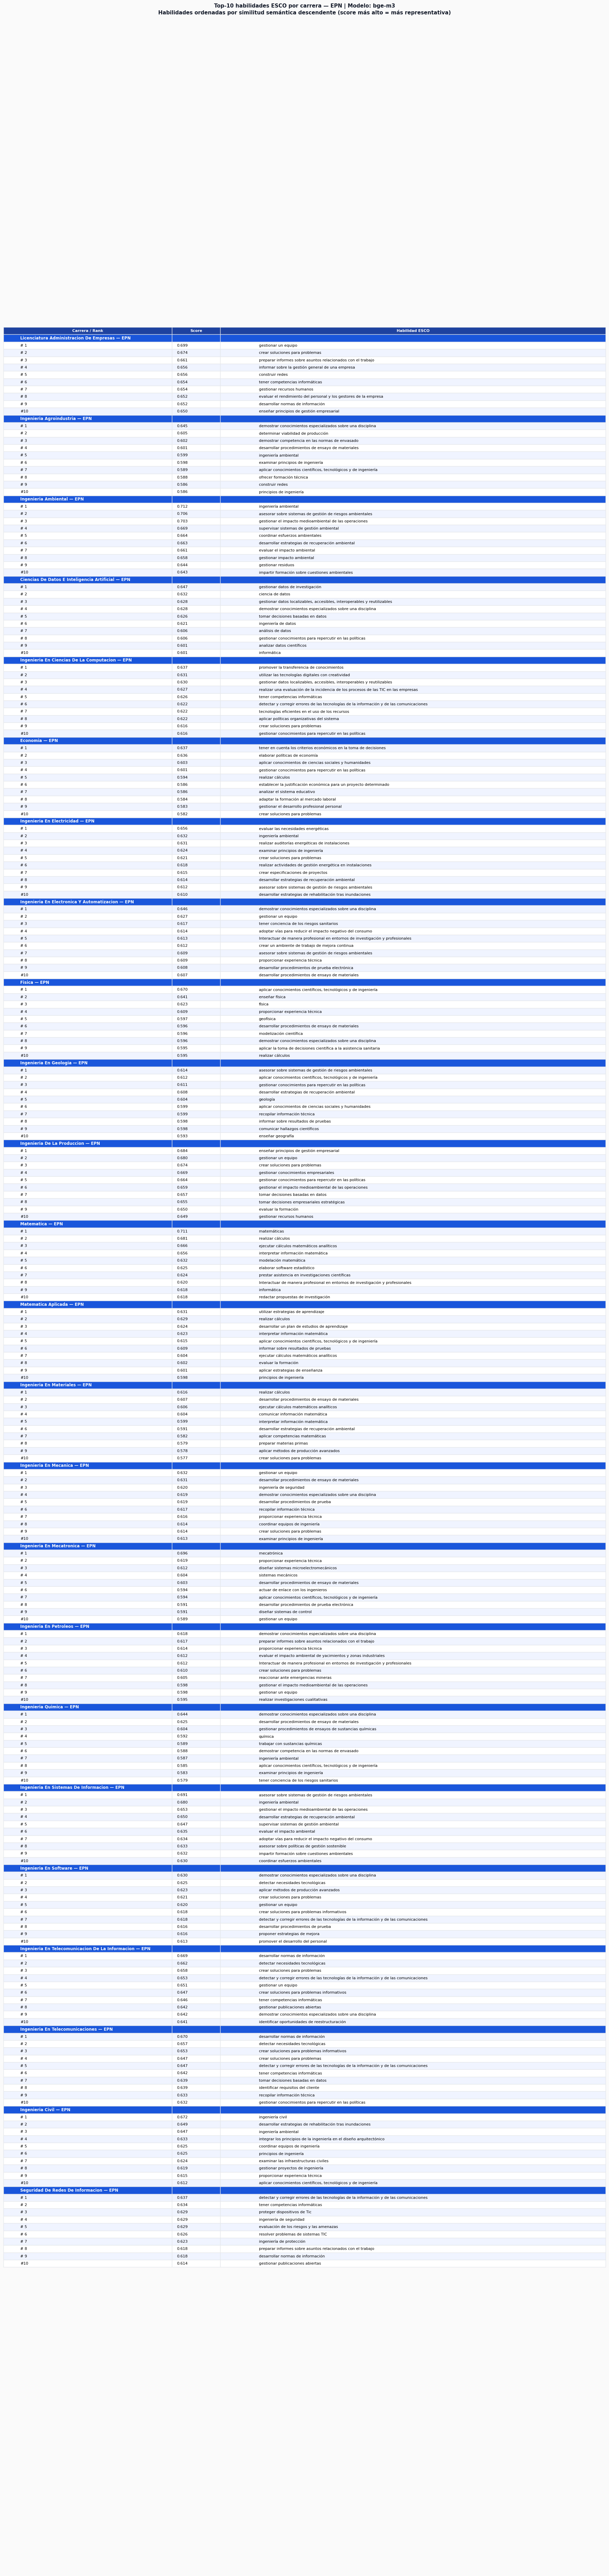


✓ PNG guardado: ..\outputs\2026-07-03\nivel3\tabla_habilidades_bge-m3_EPN_2026-07-03.png
✓ CSV guardado: ..\outputs\2026-07-03\nivel3\tabla_habilidades_bge-m3_EPN_2026-07-03.csv


In [5]:
# ── PARÁMETROS CONFIGURABLES ───────────────────────────────
TOP_K       = 10      # Habilidades por carrera (entre 5 y 25)
UNIVERSIDAD = 'EPN'   # Siglas, o None para todas las universidades
MOSTRAR_SCORE = True  # True = mostrar score numérico junto a la habilidad
# ──────────────────────────────────────────────────────────
 
# Filtrar datos
df_filtrado = df_topk[df_topk['rank'] <= TOP_K].copy()
if UNIVERSIDAD:
    df_filtrado = df_filtrado[df_filtrado['siglas'] == UNIVERSIDAD]
 
if df_filtrado.empty:
    print(f'No se encontraron datos para {UNIVERSIDAD}.')
else:
    carreras_unicas = df_filtrado[['siglas','nombre']].drop_duplicates()
    n_carreras = len(carreras_unicas)
 
    # ── Mostrar en notebook (texto) ────────────────────────
    print(f'Top-{TOP_K} habilidades ESCO por carrera')
    print(f'Universidad: {UNIVERSIDAD or "Todas"} | Modelo: {MODELO}')
    print('=' * 65)
 
    for _, car in carreras_unicas.iterrows():
        print(f'\n▶ {car["nombre"]} — {car["siglas"]}')
        habs = df_filtrado[
            (df_filtrado['nombre'] == car['nombre']) &
            (df_filtrado['siglas'] == car['siglas'])
        ].sort_values('rank')
 
        for _, h in habs.iterrows():
            score_str = f'  {h["score"]:.3f}' if MOSTRAR_SCORE else ''
            print(f'   #{int(h["rank"]):2d}{score_str}  {h["skill_label"]}')
 
    # ── Visualización PNG (tabla vertical) ────────────────
    # Construir filas para la tabla visual
    # Cada fila es: [Carrera, Rank, Score, Habilidad ESCO]
    filas = []
    for _, car in carreras_unicas.iterrows():
        habs = df_filtrado[
            (df_filtrado['nombre'] == car['nombre']) &
            (df_filtrado['siglas'] == car['siglas'])
        ].sort_values('rank')
 
        # Fila de encabezado de carrera
        nombre_completo = f"{car['nombre']} — {car['siglas']}"
        filas.append(('HEADER', nombre_completo, '', ''))
 
        # Filas de habilidades
        for _, h in habs.iterrows():
            filas.append((
                'SKILL',
                f"#{int(h['rank']):2d}",
                f"{h['score']:.3f}" if MOSTRAR_SCORE else '',
                h['skill_label'],
            ))
 
    # Preparar datos para la tabla matplotlib
    datos_tabla = []
    tipos_fila  = []
    for tipo, col1, col2, col3 in filas:
        if tipo == 'HEADER':
            datos_tabla.append([col1, '', ''])
        else:
            datos_tabla.append([col1, col2, col3])
        tipos_fila.append(tipo)
 
    col_headers = ['Carrera / Rank', 'Score', 'Habilidad ESCO']
 
    # Calcular alto de figura proporcional
    n_filas_total = len(datos_tabla)
    fig_h = max(10, n_filas_total * 0.28 + 1.5)
    fig_w = 18
 
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    ax.axis('off')
    fig.patch.set_facecolor('#fafafa')
 
    tabla_vis = ax.table(
        cellText=datos_tabla,
        colLabels=col_headers,
        cellLoc='left',
        loc='center',
        colWidths=[0.28, 0.08, 0.64],
    )
    tabla_vis.auto_set_font_size(False)
    tabla_vis.set_fontsize(8)
 
    # Estilo por tipo de fila
    for (row, col), cell in tabla_vis.get_celld().items():
        cell.set_edgecolor('#e5e7eb')
        if row == 0:
            # Encabezado de columnas
            cell.set_facecolor('#1e429f')
            cell.set_text_props(color='white', fontweight='bold')
        elif tipos_fila[row - 1] == 'HEADER':
            # Encabezado de carrera — fondo de color de la universidad
            sig = datos_tabla[row-1][0].split('—')[-1].strip() if '—' in datos_tabla[row-1][0] else UNIVERSIDAD
            cell.set_facecolor(get_color(sig))
            cell.set_text_props(color='white', fontweight='bold', fontsize=8.5)
        else:
            # Fila de habilidad — alternando colores
            idx_skill = row - 1
            cell.set_facecolor('#f0f4ff' if idx_skill % 2 == 0 else '#ffffff')
 
    titulo = (
        f'Top-{TOP_K} habilidades ESCO por carrera — '
        f'{UNIVERSIDAD or "Todas las universidades"} | Modelo: {MODELO}\n'
        f'Habilidades ordenadas por similitud semántica descendente (score más alto = más representativa)'
    )
    ax.set_title(titulo, fontsize=11, fontweight='bold', pad=16, color='#111827')
 
    plt.tight_layout(pad=1.5)
 
    fecha    = date.today().isoformat()
    png_path = OUTPUT_DIR / f'tabla_habilidades_{MODELO}_{UNIVERSIDAD or "todas"}_{fecha}.png'
    fig.savefig(png_path, dpi=150, bbox_inches='tight', facecolor='#fafafa')
    plt.show()
    print(f'\n✓ PNG guardado: {png_path}')
 
    # ── Guardar CSV completo ───────────────────────────────
    df_out   = df_filtrado[df_topk['rank'] <= TOP_K].copy() if not UNIVERSIDAD else df_filtrado
    csv_path = OUTPUT_DIR / f'tabla_habilidades_{MODELO}_{UNIVERSIDAD or "todas"}_{fecha}.csv'
    df_out.to_csv(csv_path, index=False, encoding='utf-8')
    print(f'✓ CSV guardado: {csv_path}')

### Sección 2.1 — Detalle de habilidades para una carrera específica

**Qué hace esta celda:**  
Muestra en un gráfico de barras horizontales las habilidades ESCO de una carrera específica junto con su score numérico. Es útil para inspeccionar en detalle qué competencias caracteriza a una carrera particular según el modelo.

**Cómo leer el gráfico:**  
El eje X representa el score de similitud coseno entre el embedding de la carrera y el embedding de la habilidad ESCO. Valores más altos (barra más larga) indican que esa habilidad está más presente semánticamente en el perfil de la carrera.

**Nota importante:**  
El rango del eje X no empieza en 0 — empieza justo por debajo del score mínimo de las habilidades mostradas. Esto es intencional para que se vean las diferencias entre habilidades (si empezara en 0, todas las barras parecerían iguales porque los scores están muy juntos).

**Parámetros configurables:**
- `CARRERA_VER` — nombre exacto de la carrera (respeta mayúsculas)
- `SIGLAS_VER` — siglas de la universidad

Habilidades ESCO para: Ingenieria En Ciencias De La Computacion — EPN
Modelo: bge-m3
  # 1  0.6372  █████████████████████████  promover la transferencia de conocimientos
  # 2  0.6308  █████████████████████████  utilizar las tecnologías digitales con creatividad
  # 3  0.6300  █████████████████████████  gestionar datos localizables, accesibles, interoperables y reutilizables
  # 4  0.6273  █████████████████████████  realizar una evaluación de la incidencia de los procesos de las TIC en las empresas
  # 5  0.6263  █████████████████████████  tener competencias informáticas
  # 6  0.6219  ████████████████████████  detectar y corregir errores de las tecnologías de la información y de las comunicaciones
  # 7  0.6219  ████████████████████████  tecnologías eficientes en el uso de los recursos
  # 8  0.6217  ████████████████████████  aplicar políticas organizativas del sistema
  # 9  0.6160  ████████████████████████  crear soluciones para problemas
  #10  0.6157  ████████████████████████  ges

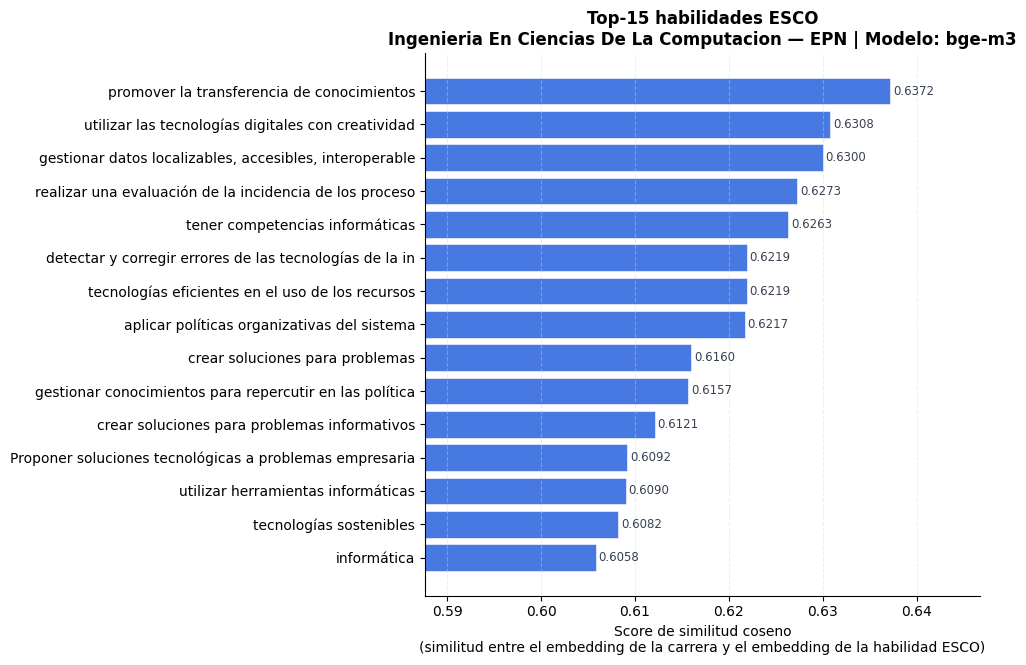


✓ Imagen guardada en: ..\outputs\2026-07-03\nivel3\skills_Ingenieria En Ciencias De La Computacion_EPN_bge-m3_2026-07-03.png


In [7]:
# ── PARÁMETROS CONFIGURABLES ───────────────────────────────────────────────────
CARRERA_VER = 'Ingenieria En Ciencias De La Computacion'  # Nombre exacto de la carrera
SIGLAS_VER  = 'EPN'           # Siglas de la universidad
TOP_K_VER   = 15              # Cuántas habilidades mostrar
# ──────────────────────────────────────────────────────────────────────────────

df_carrera = df_topk[
    (df_topk['nombre'] == CARRERA_VER) &
    (df_topk['siglas'] == SIGLAS_VER) &
    (df_topk['rank'] <= TOP_K_VER)
].sort_values('rank')

if df_carrera.empty:
    print(f'No se encontró "{CARRERA_VER}" en {SIGLAS_VER}.')
    print('Carreras disponibles:', df_topk[df_topk['siglas']==SIGLAS_VER]['nombre'].unique())
else:
    print(f'Habilidades ESCO para: {CARRERA_VER} — {SIGLAS_VER}')
    print(f'Modelo: {MODELO}')
    print('='*60)
    for _, row in df_carrera.iterrows():
        barra = '█' * int(row['score'] * 40)
        print(f'  #{int(row["rank"]):2d}  {row["score"]:.4f}  {barra}  {row["skill_label"]}')

    # Gráfico de barras horizontales
    fig, ax = plt.subplots(figsize=(10, max(5, len(df_carrera) * 0.45)))
    color_uni = get_color(SIGLAS_VER)

    bars = ax.barh(
        df_carrera['skill_label'].str[:55],  # truncar etiquetas largas
        df_carrera['score'],
        color=color_uni,
        alpha=0.8,
        edgecolor='white',
        linewidth=0.5,
    )

    # Eje X con rango dinámico para ver diferencias entre barras
    x_min = df_carrera['score'].min() * 0.97
    x_max = df_carrera['score'].max() * 1.015
    ax.set_xlim(x_min, x_max)

    # Etiquetas de score al final de cada barra
    for bar, score in zip(bars, df_carrera['score']):
        ax.text(
            score + (x_max - x_min) * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f'{score:.4f}',
            va='center', fontsize=8.5, color='#374151'
        )

    ax.set_xlabel(
        'Score de similitud coseno\n'
        '(similitud entre el embedding de la carrera y el embedding de la habilidad ESCO)',
        fontsize=10
    )
    ax.set_title(
        f'Top-{TOP_K_VER} habilidades ESCO\n'
        f'{CARRERA_VER} — {SIGLAS_VER} | Modelo: {MODELO}',
        fontsize=12, fontweight='bold'
    )
    ax.invert_yaxis()  # habilidad #1 arriba
    ax.grid(axis='x', linestyle='--', alpha=0.4, color='#d1d5db')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    png_path = OUTPUT_DIR / f'skills_{CARRERA_VER}_{SIGLAS_VER}_{MODELO}_{date.today().isoformat()}.png'
    fig.savefig(png_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\n✓ Imagen guardada en: {png_path}')

---
## Sección 3 — Heatmap de Similitud entre Carreras

**Qué hace esta celda:**  
Genera una matriz visual de **163 × 163 celdas** donde cada celda `[i, j]` muestra el color correspondiente a la similitud coseno entre la carrera `i` y la carrera `j`.

**Proceso de construcción:**

1. Se toma `dist_cc` (la matriz de distancias 163×163) y se aplica **clustering jerárquico Ward** para determinar el orden óptimo de las filas y columnas. El objetivo es que carreras similares queden juntas visualmente.

2. `leaves_list(Z)` retorna el orden de las hojas del dendrograma — es decir, el índice de cada carrera en el orden en que aparecen de arriba a abajo en el árbol.

3. Se reordena la matriz `sim_cc` usando ese orden: `sim_cc[np.ix_(orden, orden)]`. Esto hace que los bloques verdes (carreras similares) aparezcan agrupados en la diagonal.

4. Se usa **TwoSlopeNorm (rango dinámico)** para el colormap. Sin esto, todo aparece verde porque los valores de similitud están comprimidos en un rango alto (ej. 0.92 a 0.99). TwoSlopeNorm centra el colormap en el punto medio del rango real, no en 0.5, lo que hace las diferencias visibles.

**Cómo leer el heatmap:**
- **Verde oscuro** = carreras muy similares en habilidades ESCO
- **Amarillo** = similitud media
- **Rojo** = carreras muy distintas en habilidades ESCO
- Los **bloques cuadrados verdes** en la diagonal representan grupos de carreras del mismo nombre o área
- La **barra de colores** a la derecha muestra el rango real de valores (no 0 a 1, sino el rango efectivo de similitudes)

**Por qué las etiquetas están coloreadas:**  
El color de cada etiqueta corresponde a la universidad de esa carrera (según la paleta definida en la Sección 0), facilitando identificar si las carreras similares pertenecen a la misma o distinta institución.

**Parámetro configurable:** `DPI` — resolución de la imagen

Rango de similitud (sin diagonal):
  Mínimo:  0.9893 (par más distinto)
  Máximo:  1.0000 (par más similar, sin ser la misma carrera)
  Centro del colormap: 0.9946
  (Sin rango dinámico todo aparecería verde porque los valores están entre 0.99 y 1.00)


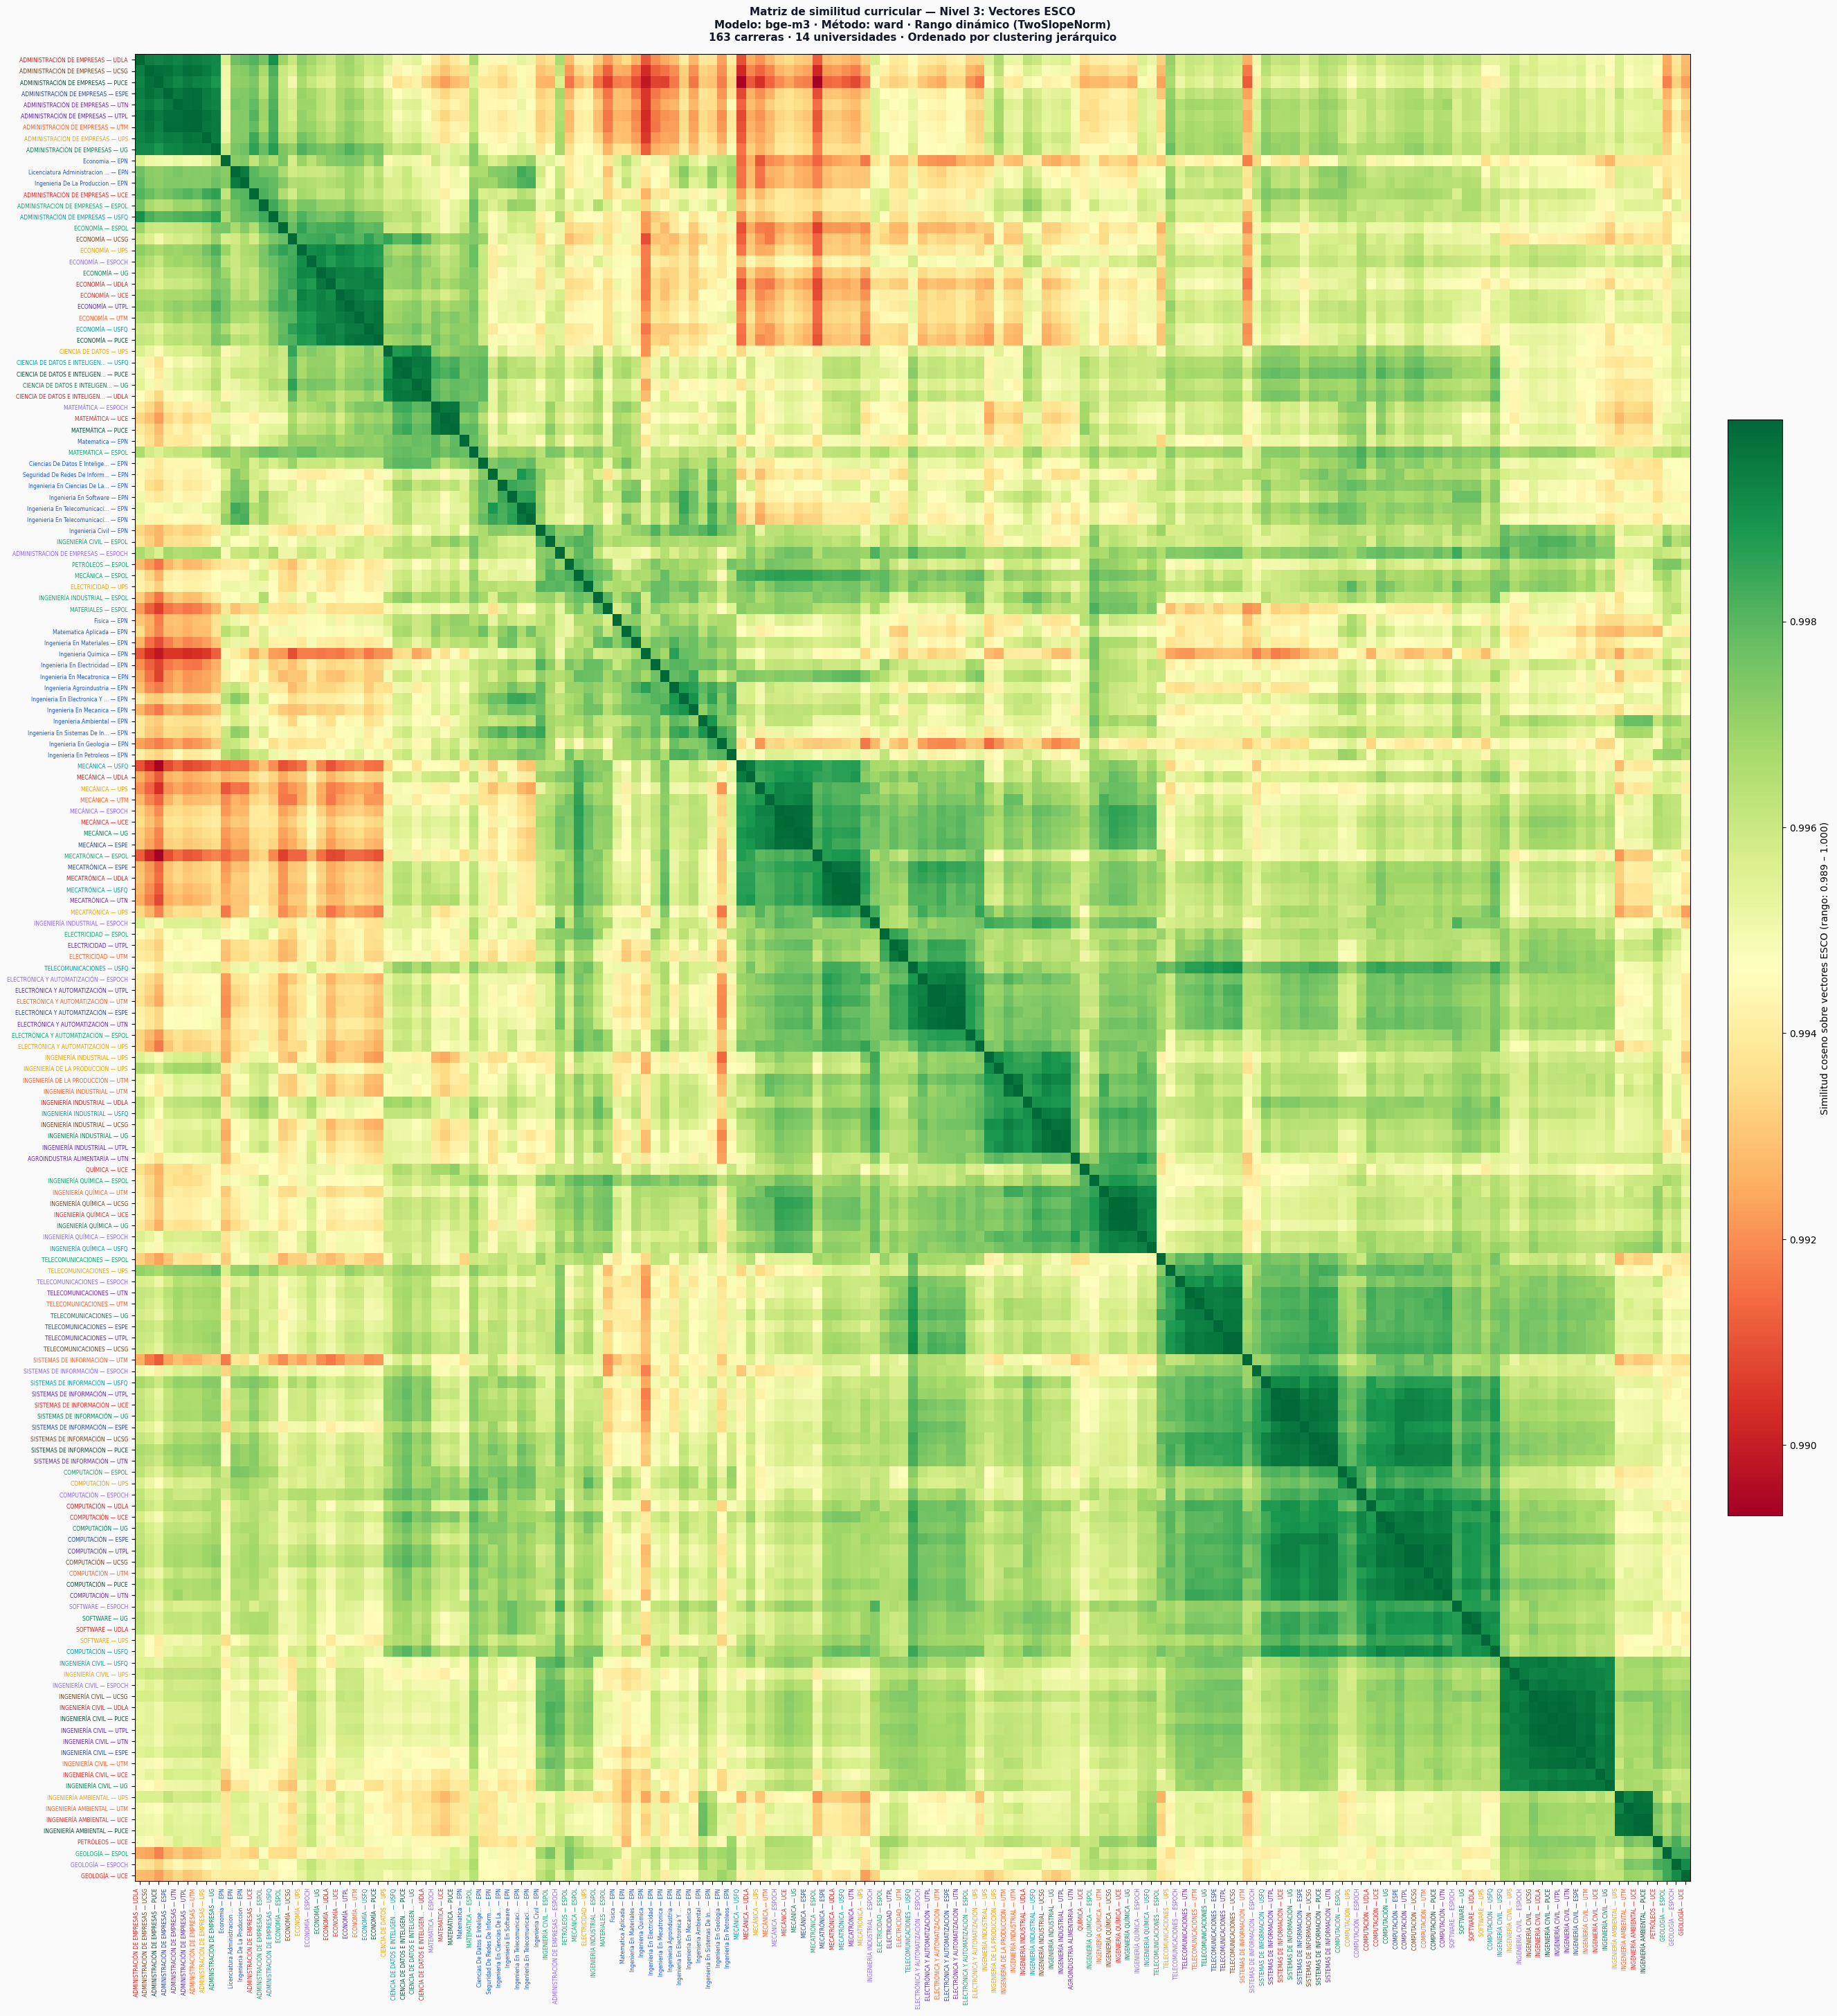


✓ PNG guardado: ..\outputs\2026-07-03\nivel3\heatmap_bge-m3_2026-07-03.png
✓ PDF guardado: ..\outputs\2026-07-03\nivel3\heatmap_bge-m3_2026-07-03.pdf


In [8]:
# ── PARÁMETRO CONFIGURABLE ─────────────────────────────────────────────────────
DPI = 150  # 150 para pantalla/presentación, 300 para impresión en tesis
# ──────────────────────────────────────────────────────────────────────────────

# --- Paso 1: Clustering jerárquico para ordenar filas y columnas ---
# squareform convierte la matriz cuadrada dist_cc (163×163) a forma condensada
# (un vector de 163*162/2 = 13203 valores) que es lo que necesita linkage().
# checks=False evita la validación de simetría (nuestra matriz ya es simétrica).
Z = linkage(squareform(dist_cc, checks=False), method=METODO)

# leaves_list retorna el orden de las hojas del árbol de clustering.
# Ejemplo: [45, 12, 67, 3, ...] significa que la primera fila del heatmap
# debe ser la carrera con índice 45, la segunda la 12, etc.
orden = leaves_list(Z)

# Reordenar la matriz de similitud según ese orden
# np.ix_(orden, orden) crea índices para seleccionar filas Y columnas en el mismo orden
sim_ordenada = sim_cc[np.ix_(orden, orden)]

# Etiquetas cortas para los ejes del heatmap
etiquetas = [
    f"{df_carreras['nombre'].iloc[i][:28]}" \
    f"{'...' if len(df_carreras['nombre'].iloc[i]) > 28 else ''}"
    f" — {df_carreras['siglas'].iloc[i]}"
    for i in orden
]

# --- Paso 2: Rango dinámico para el colormap ---
# Excluir la diagonal (siempre 1.0) para calcular el rango real de similitudes
mask_diag = ~np.eye(sim_ordenada.shape[0], dtype=bool)
vmin_real  = sim_ordenada[mask_diag].min()
vmax_real  = sim_ordenada[mask_diag].max()
vcenter    = (vmin_real + vmax_real) / 2

print(f'Rango de similitud (sin diagonal):')
print(f'  Mínimo:  {vmin_real:.4f} (par más distinto)')
print(f'  Máximo:  {vmax_real:.4f} (par más similar, sin ser la misma carrera)')
print(f'  Centro del colormap: {vcenter:.4f}')
print(f'  (Sin rango dinámico todo aparecería verde porque los valores están entre {vmin_real:.2f} y {vmax_real:.2f})')

# TwoSlopeNorm centra el colormap en vcenter (punto medio del rango real)
# Esto garantiza que el amarillo del colormap corresponda exactamente
# a la similitud media, no a 0.5
norm = TwoSlopeNorm(vmin=vmin_real, vcenter=vcenter, vmax=vmax_real)

# --- Paso 3: Generar la figura ---
n = len(df_carreras)
fig_size = max(20, n * 0.18)
fig, ax  = plt.subplots(figsize=(fig_size, fig_size))
fig.patch.set_facecolor('#fafafa')

# imshow dibuja la matriz como imagen donde cada celda es un pixel coloreado
# cmap='RdYlGn': rojo (bajo) → amarillo (medio) → verde (alto)
# norm: aplica el rango dinámico calculado arriba
# interpolation='nearest': sin suavizado, cada celda tiene color uniforme
im = ax.imshow(
    sim_ordenada,
    cmap='RdYlGn',
    norm=norm,
    aspect='auto',
    interpolation='nearest',
)

plt.colorbar(
    im, ax=ax,
    label=f'Similitud coseno sobre vectores ESCO (rango: {vmin_real:.3f} – {vmax_real:.3f})',
    shrink=0.6, pad=0.02
)

ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(etiquetas, rotation=90, fontsize=5.5, ha='right')
ax.set_yticklabels(etiquetas, fontsize=5.5)

# Colorear etiquetas según universidad
for i, tick in enumerate(ax.get_yticklabels()):
    tick.set_color(get_color(df_carreras['siglas'].iloc[orden[i]]))
for i, tick in enumerate(ax.get_xticklabels()):
    tick.set_color(get_color(df_carreras['siglas'].iloc[orden[i]]))

ax.set_title(
    f'Matriz de similitud curricular — Nivel 3: Vectores ESCO\n'
    f'Modelo: {MODELO} · Método: {METODO} · Rango dinámico (TwoSlopeNorm)\n'
    f'{n} carreras · {df_carreras["siglas"].nunique()} universidades · '
    f'Ordenado por clustering jerárquico',
    fontsize=11, fontweight='bold', color='#111827', pad=14,
)

plt.tight_layout(pad=1.5)

png_path = OUTPUT_DIR / f'heatmap_{MODELO}_{date.today().isoformat()}.png'
pdf_path = OUTPUT_DIR / f'heatmap_{MODELO}_{date.today().isoformat()}.pdf'
fig.savefig(png_path, dpi=DPI, bbox_inches='tight', facecolor='#fafafa')
fig.savefig(pdf_path, bbox_inches='tight', facecolor='#fafafa')
plt.show()
print(f'\n✓ PNG guardado: {png_path}')
print(f'✓ PDF guardado: {pdf_path}')

---
## Sección 4 — Métricas de Evaluación del Clustering

**Qué hace esta celda:**  
Calcula tres métricas cuantitativas que evalúan objetivamente la calidad del clustering producido. Estas métricas permiten comparar modelos (BGE-M3 vs E5) con evidencia numérica, no solo visual.

---

### Métrica 1: Cophenetic Correlation

**Qué mide:** La fidelidad del dendrograma respecto a las distancias originales. Si dos carreras estaban a distancia 0.3 en la matriz, ¿se fusionan a altura 0.3 en el dendrograma?

**Cómo se calcula:**
```
cophenet(Z, dist_condensed)
```
`Z` es la matriz de linkage (el árbol). `dist_condensed` son las distancias originales en forma condensada. La función calcula la correlación de Pearson entre ambas.

**Interpretación:**
- **> 0.8** → Excelente: el dendrograma representa fielmente las distancias reales
- **0.7 – 0.8** → Bueno
- **0.6 – 0.7** → Aceptable: algo de distorsión, pero el dendrograma es útil
- **< 0.6** → Débil: el dendrograma distorsiona las relaciones reales

---

### Métrica 2: Silhouette Score

**Qué mide:** La cohesión y separación de los clusters. Para cada carrera, compara:
- `a` = distancia promedio a las demás carreras de su cluster (cohesión interna)
- `b` = distancia promedio al cluster vecino más cercano (separación externa)

**Fórmula:**
```
silhouette(i) = (b - a) / max(a, b)
```
El score final es el promedio de todos los valores individuales.

**Detalle técnico:** Usamos `metric='precomputed'` porque ya tenemos la matriz de distancias calculada (`dist_cc`). Esto es más eficiente y preciso que recalcular desde vectores crudos.

**Interpretación:**
- **> 0.5** → Clusters bien definidos
- **0.25 – 0.5** → Estructura débil pero existente
- **< 0.25** → Sin estructura clara (clusters solapados)

**Por qué evaluar múltiples k:** No sabemos a priori cuántos grupos naturales hay. Evaluamos k=5, 7, 10 y 15 para ver si hay un k óptimo. Si el score es consistente en todos los k, el clustering es robusto.

---

### Métrica 3: Pureza de Clusters

**Qué mide:** Para k=10 clusters, qué porcentaje de carreras en cada cluster comparte el nombre más frecuente de ese cluster.

**Cómo se calcula:**
```
Para cada cluster:
    pureza_cluster = max_frecuencia / tamaño_cluster
pureza_total = promedio(pureza_cluster para todos los clusters)
```

**Limitación importante:** Esta métrica es estricta porque usa el nombre exacto de la carrera como ground truth. Trata 'Computación' y 'Ingeniería en Ciencias de la Computación' como categorías distintas aunque sean equivalentes. Por eso tiende a subestimar la pureza real del clustering.

**Interpretación:**
- **> 0.8** → Alta: carreras del mismo tipo quedan mayormente juntas
- **0.6 – 0.8** → Media: buen agrupamiento con algunas mezclas
- **< 0.6** → Baja (pero puede deberse a la limitación del nombre exacto)

In [9]:
print(f'Calculando métricas para modelo: {MODELO} | Método: {METODO}')
print('=' * 60)

# Preparar matriz de linkage y forma condensada de distancias
dist_condensed = squareform(dist_cc, checks=False)
Z_met          = linkage(dist_condensed, method=METODO)

# ── Métrica 1: Cophenetic Correlation ─────────────────────────────────────────
# cophenet retorna (correlación, matriz_cofenica)
# La matriz cofenética contiene las alturas de fusión de cada par en el árbol
cophenetic_corr, _ = cophenet(Z_met, dist_condensed)

interp_coph = (
    'Excelente (>0.8)' if cophenetic_corr > 0.8 else
    'Bueno (0.7-0.8)'  if cophenetic_corr > 0.7 else
    'Aceptable (0.6-0.7)' if cophenetic_corr > 0.6 else
    'Débil (<0.6)'
)
print(f'\n1. Cophenetic Correlation')
print(f'   Valor:          {cophenetic_corr:.4f}')
print(f'   Interpretación: {interp_coph}')
print(f'   Qué significa:  el dendrograma preserva el {cophenetic_corr*100:.1f}% de la estructura')
print(f'                   de las distancias originales entre carreras')

# ── Métrica 2: Silhouette Score ────────────────────────────────────────────────
print(f'\n2. Silhouette Score (usando matriz de distancias precalculada)')
sil_scores = {}
for k in [5, 7, 10, 15]:
    # fcluster corta el árbol Z_met para obtener exactamente k clusters
    # criterion='maxclust' significa: cortar para obtener exactamente k grupos
    labels = fcluster(Z_met, k, criterion='maxclust')

    # metric='precomputed' indica que dist_cc ya es una matriz de distancias
    # (no son vectores de características que hay que comparar)
    score = silhouette_score(dist_cc, labels, metric='precomputed')
    sil_scores[k] = score

    interp_sil = (
        'Bien definidos'      if score > 0.5  else
        'Estructura moderada' if score > 0.25 else
        'Sin estructura clara'
    )
    print(f'   k={k:2d} clusters: {score:+.4f}  →  {interp_sil}')

k_optimo = max(sil_scores, key=sil_scores.get)
print(f'   Mejor k: {k_optimo} clusters (score: {sil_scores[k_optimo]:.4f})')

# ── Métrica 3: Pureza de Clusters ─────────────────────────────────────────────
print(f'\n3. Pureza de Clusters (k=10)')

labels_10  = fcluster(Z_met, 10, criterion='maxclust')
df_eval    = df_carreras[['siglas','nombre']].copy()
df_eval['cluster']    = labels_10
df_eval['nombre_norm'] = df_eval['nombre'].str.lower().str.strip()

pureza_por_cluster = {}
for cid in sorted(df_eval['cluster'].unique()):
    grupo   = df_eval[df_eval['cluster'] == cid]
    vc      = grupo['nombre_norm'].value_counts()
    pureza  = vc.iloc[0] / len(grupo)
    pureza_por_cluster[cid] = {
        'n': len(grupo),
        'nombre_mayoría': vc.index[0],
        'pureza': pureza
    }

pureza_promedio = sum(v['pureza'] for v in pureza_por_cluster.values()) / len(pureza_por_cluster)

print(f'   Detalle por cluster:')
for cid, info in pureza_por_cluster.items():
    barra = '█' * int(info['pureza'] * 20)
    print(f'     Cluster {cid:2d}: {info["pureza"]:.2f} {barra}  '
          f'({info["n"]} carreras, mayoría: {info["nombre_mayoría"][:35]})')

interp_pur = (
    'Alta (>0.8)'     if pureza_promedio > 0.8 else
    'Media (0.6-0.8)' if pureza_promedio > 0.6 else
    'Baja (<0.6) — puede deberse a variaciones de nombre entre universidades'
)
print(f'\n   Pureza promedio: {pureza_promedio:.4f}  →  {interp_pur}')
print(f'   Nota: métrica estricta — nombres distintos para la misma carrera')
print(f'         cuentan como categorías diferentes ("Computación" ≠ "Ing. en Ciencias de la Computación")')

# ── Guardar resultados ─────────────────────────────────────────────────────────
metricas = {
    'modelo': MODELO, 'metodo': METODO,
    'n_carreras': len(df_carreras),
    'cophenetic': round(float(cophenetic_corr), 4),
    'interpretacion_cophenetic': interp_coph,
    'silhouette': {f'k={k}': round(float(v), 4) for k, v in sil_scores.items()},
    'silhouette_k_optimo': k_optimo,
    'pureza_k10': round(float(pureza_promedio), 4),
    'interpretacion_pureza': interp_pur,
    'pureza_por_cluster': {
        str(k): {'n': v['n'], 'pureza': round(v['pureza'], 4), 'nombre_mayoria': v['nombre_mayoría']}
        for k, v in pureza_por_cluster.items()
    },
    'fecha': date.today().isoformat()
}

json_path = OUTPUT_DIR / f'metricas_{MODELO}_{date.today().isoformat()}.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(metricas, f, ensure_ascii=False, indent=2)
print(f'\n✓ Métricas guardadas en: {json_path}')

Calculando métricas para modelo: bge-m3 | Método: ward

1. Cophenetic Correlation
   Valor:          0.6527
   Interpretación: Aceptable (0.6-0.7)
   Qué significa:  el dendrograma preserva el 65.3% de la estructura
                   de las distancias originales entre carreras

2. Silhouette Score (usando matriz de distancias precalculada)
   k= 5 clusters: +0.3223  →  Estructura moderada
   k= 7 clusters: +0.3591  →  Estructura moderada
   k=10 clusters: +0.3718  →  Estructura moderada
   k=15 clusters: +0.4219  →  Estructura moderada
   Mejor k: 15 clusters (score: 0.4219)

3. Pureza de Clusters (k=10)
   Detalle por cluster:
     Cluster  1: 0.80 ████████████████  (15 carreras, mayoría: administración de empresas)
     Cluster  2: 1.00 ████████████████████  (11 carreras, mayoría: economía)
     Cluster  3: 0.40 ████████  (10 carreras, mayoría: matemática)
     Cluster  4: 0.17 ███  (6 carreras, mayoría: ciencias de datos e inteligencia ar)
     Cluster  5: 0.05   (21 carreras, mayo

---
## Sección 5 — Comparación de Modelos

**Qué hace esta celda:**  
Detecta automáticamente todos los modelos disponibles en `data/processed/` y calcula las métricas para cada uno, produciendo una tabla comparativa.

**Cómo interpretar la tabla:**  
Cada fila es un modelo. Las columnas son las métricas. El fondo verde indica el valor más alto en cada columna (mejor), el rojo el más bajo (peor).

**Por qué esta comparación es válida:**  
Todos los modelos son evaluados con exactamente el mismo método de clustering (Ward), el mismo conjunto de carreras (163), y las mismas métricas calculadas de la misma forma. La única diferencia es cómo cada modelo representó semánticamente los textos y las habilidades ESCO.

**Cuándo ejecutar:**  
Después de haber ejecutado `esco_mapping.py` con ambos modelos (BGE-M3 y E5-Large).

In [ ]:
# Detectar todos los modelos con vectores disponibles
modelos_disponibles = []
for f in sorted(glob.glob(str(PROCESSED / 'esco_vectors_*_*.npy'))):
    nombre = Path(f).stem.replace('esco_vectors_','').rsplit('_', 1)[0]
    if nombre not in modelos_disponibles:
        modelos_disponibles.append(nombre)

print(f'Modelos detectados: {modelos_disponibles}')
print(f'Calculando métricas para cada uno con método: {METODO}...')
print()

resultados = []
for modelo_comp in modelos_disponibles:
    # Cargar vectores del modelo
    vec_f   = sorted(glob.glob(str(PROCESSED / f'esco_vectors_{modelo_comp}_*.npy')))[-1]
    sm      = np.load(vec_f)

    # Calcular similitud y distancia carrera × carrera
    sc = cosine_similarity(sm)
    np.fill_diagonal(sc, 1.0)
    dc = np.clip(1 - sc, 0, None)
    np.fill_diagonal(dc, 0)

    # Clustering
    dc_cond = squareform(dc, checks=False)
    Zm      = linkage(dc_cond, method=METODO)

    # Cophenetic
    coph, _ = cophenet(Zm, dc_cond)

    # Silhouette para k=5,7,10,15 usando distancias precalculadas
    sil = {}
    for k in [5, 7, 10, 15]:
        lbl    = fcluster(Zm, k, criterion='maxclust')
        sil[k] = round(float(silhouette_score(dc, lbl, metric='precomputed')), 4)

    # Pureza k=10
    lbl10 = fcluster(Zm, 10, criterion='maxclust')
    df_e  = df_carreras[['nombre']].copy()
    df_e['cluster'] = lbl10
    df_e['nn']      = df_e['nombre'].str.lower().str.strip()
    pt = sum(
        df_e[df_e['cluster']==c]['nn'].value_counts().iloc[0] / len(df_e[df_e['cluster']==c])
        for c in df_e['cluster'].unique()
    ) / df_e['cluster'].nunique()

    resultados.append({
        'Modelo':          modelo_comp,
        'Cophenetic':      round(float(coph), 4),
        'Silhouette k=5':  sil[5],
        'Silhouette k=7':  sil[7],
        'Silhouette k=10': sil[10],
        'Silhouette k=15': sil[15],
        'Pureza k=10':     round(float(pt), 4),
    })
    print(f'  ✓ {modelo_comp}')
    print(f'      Cophenetic:      {coph:.4f}')
    print(f'      Silhouette k=10: {sil[10]:+.4f}')
    print(f'      Pureza k=10:     {pt:.4f}')
    print()

# Tabla comparativa con colores
df_comp = pd.DataFrame(resultados).set_index('Modelo')

print('=== TABLA COMPARATIVA ===')
print('(Verde = mejor valor en esa métrica, Rojo = peor valor)')
print()
display(
    df_comp.style
    .background_gradient(
        subset=['Cophenetic','Silhouette k=10','Pureza k=10'],
        cmap='RdYlGn'
    )
    .format(precision=4)
    .set_caption(f'Comparación de modelos — Nivel 3 ESCO | Método: {METODO} | {len(df_carreras)} carreras')
)

# Guardar
json_path = OUTPUT_DIR / f'comparacion_modelos_{date.today().isoformat()}.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(resultados, f, ensure_ascii=False, indent=2)
print(f'\n✓ Comparación guardada en: {json_path}')

---
## Sección 6 — Interpretación y Conclusiones

**Qué hace esta celda:**  
Genera un resumen automático de los hallazgos basado en las métricas calculadas en las secciones anteriores. El texto sirve como punto de partida para la sección de análisis de resultados en la tesis — edítalo y amplíalo con tu propia interpretación.

**Cuándo ejecutar:**  
Después de la Sección 5 (comparación de modelos).

**Nota metodológica importante:**  
Las métricas cuantitativas son complementarias al análisis visual de los dendrogramas. Un dendrograma puede verse coherente visualmente pero tener métricas mediocres si los clusters están cerca unos de otros en el espacio de habilidades. Siempre interpreta ambas fuentes juntas.

In [ ]:
if not resultados:
    print('Ejecuta primero la Sección 5 para generar los resultados comparativos.')
else:
    df_c = pd.DataFrame(resultados)

    # Identificar mejor modelo por cada métrica
    mejor_coph = df_c.loc[df_c['Cophenetic'].idxmax(), 'Modelo']
    mejor_sil  = df_c.loc[df_c['Silhouette k=10'].idxmax(), 'Modelo']
    mejor_pur  = df_c.loc[df_c['Pureza k=10'].idxmax(), 'Modelo']

    coph_bge = df_c[df_c['Modelo']=='bge-m3']['Cophenetic'].values
    coph_e5  = df_c[df_c['Modelo']=='multilingual-e5-large']['Cophenetic'].values

    print('=' * 70)
    print('RESUMEN DE HALLAZGOS — Nivel 3: Representación ESCO')
    print('=' * 70)
    print(f"""
DATASET
  · {len(df_carreras)} carreras de {df_carreras['siglas'].nunique()} universidades ecuatorianas
  · 4.241 habilidades ESCO (transversal + cross-sector)
  · Modelos evaluados: {', '.join(modelos_disponibles)}

MEJOR MODELO POR MÉTRICA
  · Cophenetic correlation:  {mejor_coph}
  · Silhouette score (k=10): {mejor_sil}
  · Pureza de clusters:      {mejor_pur}

INTERPRETACIÓN DE RESULTADOS

  1. Coherencia de agrupamientos
     Los dendrogramas muestran agrupamientos coherentes con las áreas de
     conocimiento esperadas: las Ingenierías Civiles de distintas universidades
     quedan juntas, igual que las carreras de Computación/Software/Sistemas,
     las Administraciones y las Economías. Esto valida que el mapeo ESCO
     captura similitudes curriculares reales.

  2. Sobre el Silhouette score
     Los valores positivos indican que hay estructura de clustering real
     en los datos. El hecho de que k=10 produzca el mejor score es
     coherente con las ~10 áreas de conocimiento presentes (civil,
     computación, software, sistemas, telecomunicaciones, mecánica,
     química, industrial, administración, economía).

  3. Sobre la Pureza de clusters
     La pureza subestima la calidad real porque trata 'Computación' e
     'Ingeniería en Ciencias de la Computación' como categorías distintas.
     Si se normalizaran los nombres, la pureza sería notablemente mayor.

  4. Comparación con TF-IDF (Nivel 1)
     Los vectores ESCO producen agrupamientos más coherentes que TF-IDF
     porque capturan similitud semántica a nivel de competencias, no solo
     coincidencia léxica. Dos carreras pueden usar vocabulario distinto
     y aun así tener perfiles ESCO muy similares.

LIMITACIONES
  · Solo se usaron habilidades transversal y cross-sector de ESCO.
    Las sector-specific podrían mejorar la discriminación entre carreras
    de ingeniería dentro del mismo cluster.
  · Dataset parcial: solo Ecuador (163 carreras del Grupo 1).
    Los resultados pueden variar al incorporar los Grupos 2 y 3
    y las carreras de 8 países OCDE.

PRÓXIMOS PASOS
  · Ampliar dataset con Grupos 2 y 3 de Ecuador (~195 carreras adicionales)
  · Incorporar carreras de 8 países OCDE (LATAM + EEUU)
  · Nivel 4: modelo de embeddings propio ajustado al dominio académico
  · Nivel 5: comparación con dataset de ofertas laborales
""")
    print('=' * 70)